# Evolution of Adversarial Attractors across $\varepsilon$ values

In this notebook, we analyze how the strength of the adversarial perturbation ($\varepsilon$) affects the "latent space collapse". 

Our hypothesis is that as the perturbation magnitude increases, the diversity of the predicted classes drops dramatically. Instead of dispersing randomly, a stronger attack forces the majority of the dataset to collapse into a very small number of universal "sink classes" (attractors). 

We will track two metrics across increasing $\varepsilon$ values:
1. **Unique Adversarial Classes:** How many different classes the 100 original images are mapped to.
2. **Top-1 Attractor Dominance:** What percentage of the dataset is swallowed by the single most dominant sink class.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from collections import Counter

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import preprocessing and decoding
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff, decode_predictions as decode_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc, decode_predictions as decode_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob, decode_predictions as decode_mob

In [2]:
# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob,
        'eps_scale': 1.0
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff,
        'eps_scale': 127.5
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc,
        'eps_scale': 1.0
    }
}

# Freeze weights as we only need to perform inference and compute gradients w.r.t inputs
for config in models_dict.values():
    config['model'].trainable = False

### Helper Functions & Data Loading

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

In [4]:
# Define the path to the 100 images folder
dataset_path = '../images/miniimagenet_random_100/'
image_paths = glob.glob(os.path.join(dataset_path, '*.*'))

# Limit to 100 just in case
image_paths = image_paths[:100]
print(f"Total images loaded for the experiment: {len(image_paths)}")

Total images loaded for the experiment: 100


In [5]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(input_image, input_label, epsilon, current_model):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = current_model(input_image)
        loss = loss_object(input_label, prediction)
    
    # Get gradients of the loss w.r.t to the input image
    gradient = tape.gradient(loss, input_image)
    
    # Get the sign of the gradients
    signed_grad = tf.sign(gradient)
    
    # Create the adversarial image
    adv_image = input_image + epsilon * signed_grad
    return adv_image

### Evaluate Attractor Collapse over $\varepsilon$
We will test several $\varepsilon$ values. For each step, we record the total number of unique classes predicted and the percentage of images classified into the single most dominant class.

In [6]:
# List of epsilons to evaluate
base_epsilons = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]

# Dictionary to store the temporal evolution
evolution_data = {}

for model_name, m_config in models_dict.items():
    print(f"\n{'='*80}")
    print(f"EVALUATING EPSILON EVOLUTION FOR: {model_name}")
    print(f"{'='*80}\n")
    
    current_model = m_config['model']
    target_size = m_config['target_size']
    preprocess_fn = m_config['preprocess_fn']
    
    unique_classes_per_eps = []
    top1_dominance_per_eps = []
    
    # Compute original predictions to have a baseline (epsilon = 0)
    orig_predictions = []
    for img_path in image_paths:
        input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)
        orig_probs = current_model(input_img, training=False)
        orig_idx = tf.argmax(orig_probs, axis=-1).numpy()[0]
        orig_predictions.append(orig_idx)
        
    baseline_unique = len(set(orig_predictions))
    baseline_top1 = Counter(orig_predictions).most_common(1)[0][1] / len(image_paths) * 100
    
    unique_classes_per_eps.append(baseline_unique)
    top1_dominance_per_eps.append(baseline_top1)
    
    print(f"Baseline (Eps=0.0): Unique Classes = {baseline_unique}, Top-1 Dominance = {baseline_top1:.1f}%")
    
    # Iterate over increasing epsilon values
    for base_eps in base_epsilons:
        epsilon = base_eps * m_config['eps_scale']
        adv_predictions = []
        
        for i, img_path in enumerate(image_paths):
            input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)
            
            # Label needed for the attack
            orig_probs = current_model(input_img, training=False)
            orig_idx = tf.argmax(orig_probs, axis=-1).numpy()[0]
            input_label = tf.reshape(tf.one_hot(orig_idx, orig_probs.shape[-1]), (1, -1))
            
            # Attack and predict
            adv_img = fgsm_attack(input_img, input_label, epsilon, current_model)
            adv_probs = current_model(adv_img, training=False)
            adv_idx = tf.argmax(adv_probs, axis=-1).numpy()[0]
            adv_predictions.append(adv_idx)
            
        # Calculate metrics for this epsilon
        num_unique = len(set(adv_predictions))
        top1_dom = Counter(adv_predictions).most_common(1)[0][1] / len(image_paths) * 100
        
        unique_classes_per_eps.append(num_unique)
        top1_dominance_per_eps.append(top1_dom)
        print(f"Eps={base_eps}: Unique Classes = {num_unique}, Top-1 Dominance = {top1_dom:.1f}%")
        
    evolution_data[model_name] = {
        'unique_classes': unique_classes_per_eps,
        'top1_dominance': top1_dominance_per_eps
    }


EVALUATING EPSILON EVOLUTION FOR: MobileNetV2

Baseline (Eps=0.0): Unique Classes = 86, Top-1 Dominance = 4.0%
Eps=0.001: Unique Classes = 85, Top-1 Dominance = 3.0%
Eps=0.01: Unique Classes = 93, Top-1 Dominance = 3.0%
Eps=0.05: Unique Classes = 91, Top-1 Dominance = 2.0%
Eps=0.1: Unique Classes = 58, Top-1 Dominance = 9.0%
Eps=0.2: Unique Classes = 19, Top-1 Dominance = 31.0%
Eps=0.3: Unique Classes = 16, Top-1 Dominance = 35.0%

EVALUATING EPSILON EVOLUTION FOR: EfficientNetB0

Baseline (Eps=0.0): Unique Classes = 89, Top-1 Dominance = 3.0%
Eps=0.001: Unique Classes = 94, Top-1 Dominance = 2.0%
Eps=0.01: Unique Classes = 89, Top-1 Dominance = 4.0%
Eps=0.05: Unique Classes = 92, Top-1 Dominance = 3.0%
Eps=0.1: Unique Classes = 84, Top-1 Dominance = 4.0%
Eps=0.2: Unique Classes = 61, Top-1 Dominance = 7.0%
Eps=0.3: Unique Classes = 57, Top-1 Dominance = 9.0%

EVALUATING EPSILON EVOLUTION FOR: InceptionV3

Baseline (Eps=0.0): Unique Classes = 90, Top-1 Dominance = 3.0%
Eps=0.001: Uniq

### Visualization: Latent Space Collapse

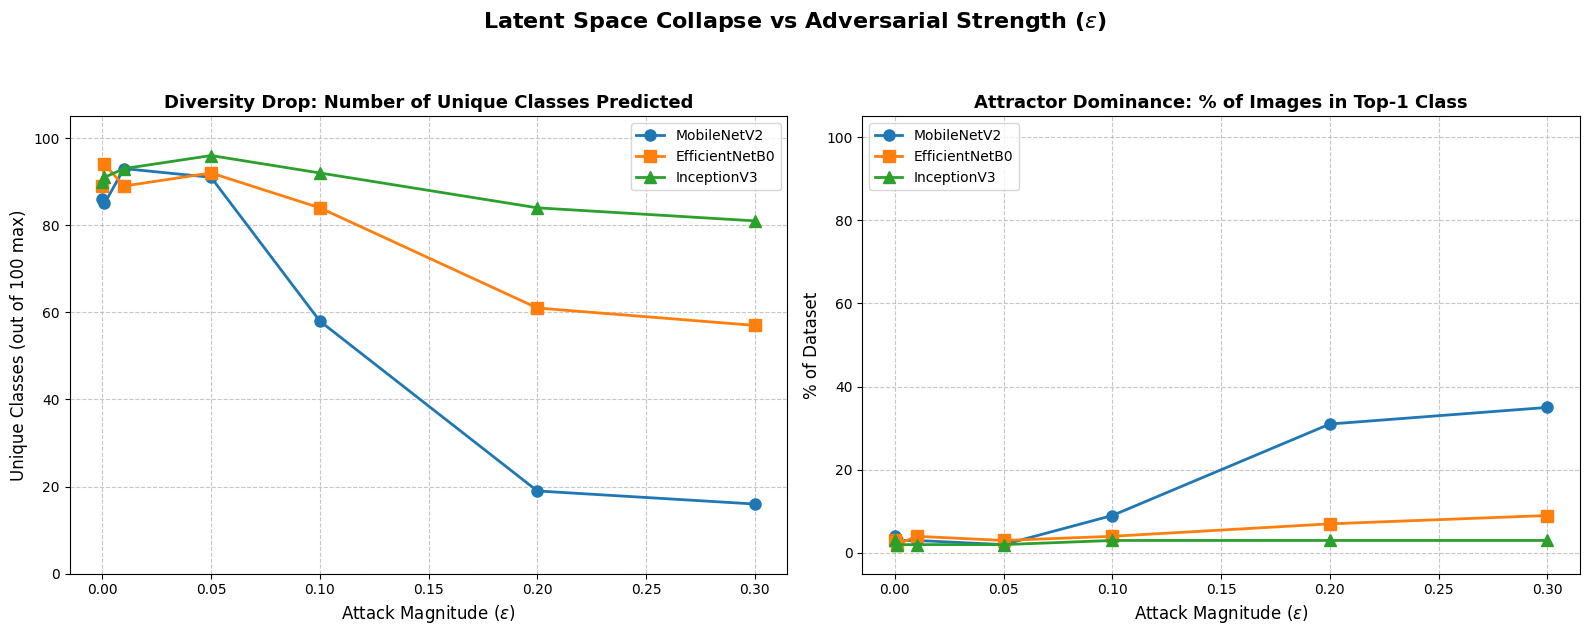

In [7]:
# X-axis values (0 added for the baseline)
x_values = [0.0] + base_epsilons

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Latent Space Collapse vs Adversarial Strength ($\epsilon$)', fontsize=16, fontweight='bold', y=1.05)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for i, (model_name, data) in enumerate(evolution_data.items()):
    
    # Plot 1: Unique Classes
    ax1.plot(x_values, data['unique_classes'], color=colors[i], marker=markers[i], lw=2, markersize=8, label=model_name)
    
    # Plot 2: Top-1 Dominance
    ax2.plot(x_values, data['top1_dominance'], color=colors[i], marker=markers[i], lw=2, markersize=8, label=model_name)

# Formatting Plot 1
ax1.set_title('Diversity Drop: Number of Unique Classes Predicted', fontsize=13, fontweight='bold')
ax1.set_xlabel('Attack Magnitude ($\epsilon$)', fontsize=12)
ax1.set_ylabel('Unique Classes (out of 100 max)', fontsize=12)
ax1.set_ylim(0, 105)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.7)

# Formatting Plot 2
ax2.set_title('Attractor Dominance: % of Images in Top-1 Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Attack Magnitude ($\epsilon$)', fontsize=12)
ax2.set_ylabel('% of Dataset', fontsize=12)
ax2.set_ylim(-5, 105)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()